Here, we fit PLS models on subsets of the actual data, which will be used in downstream analyses instead of the global PLS fit in Notebook 04. 

We ensure that the Q2Y p-value is less than or equal to 0.05 for all PLS model fits. 

In [1]:
import os
from contextlib import contextmanager
import copy
import warnings
import sys
import math

from tqdm import trange, tqdm

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../.') 
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [4]:
def clear_adata(adata):
    for k in copy.deepcopy(adata.obsm.keys()):
        del adata.obsm[k]
    for k in copy.deepcopy(adata.varm.keys()):
        del adata.varm[k]
    for k in copy.deepcopy(adata.obsp.keys()):
        del adata.obsp[k]
    
    return adata

@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

In [5]:
# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

def run_pls_(tf_adata_test, n_components = None):
    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_test, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'perturbation', # actually separating by condition 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    pls_model = models['pls_model']

    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant for fold: {}'.format(fold)
    X_pls_transform = pls_model.transform(tf_adata_test.X)
    assert np.allclose(X_pls_transform, X_pls), 'Something is missing between model fit and transform'
    
    return pls_model

In [18]:
def condition_specific_PLS(fold, n_components = None, include_control = False):
    """Fits PLS models specific to a fold test condition. Y-block is now condition rather than perturbation."""

    split = get_split(fold, author)
    test_conds = split['test_conds']
    if include_control:
        ctrl_conds = list(set('^'.join([tc.split('^')[0], ctrl_pert]) for tc in test_conds))
        test_conds += ctrl_conds

    test_cond_mask = tf_adata.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata[test_cond_mask,:].copy()

    tf_adata_test = clear_adata(tf_adata_test)
    
    # hacky way of running ls.pls_da, that only allows pert_col or cat_col
    tf_adata_test.obs[pert_col] = tf_adata_test.obs['condition'].copy()
    
    pls_model = run_pls_(tf_adata_test = tf_adata_test, n_components = n_components)
    
    return pls_model

# Test conditions combined

Here, we fit PLS models specifically to the subset of test conditions in a given fold, The response is now the condition (cell type + perturbation) rather than perturbation. 

In [32]:
condition_specific_pls_models = {}
for fold in trange(5):
    condition_specific_pls_models[fold] = condition_specific_PLS(fold, n_components = None, include_control = False)

100%|█████████████████████████████████████████████| 5/5 [01:14<00:00, 14.93s/it]


Fold: 1 | 5 components | Q2Y 0.752 (p = 9.90E-03)
Fold: 2 | 3 components | Q2Y 0.859 (p = 9.90E-03)
Fold: 3 | 4 components | Q2Y 0.910 (p = 9.90E-03)
Fold: 4 | 2 components | Q2Y 0.443 (p = 9.90E-03)
Fold: 5 | 2 components | Q2Y 0.888 (p = 9.90E-03)


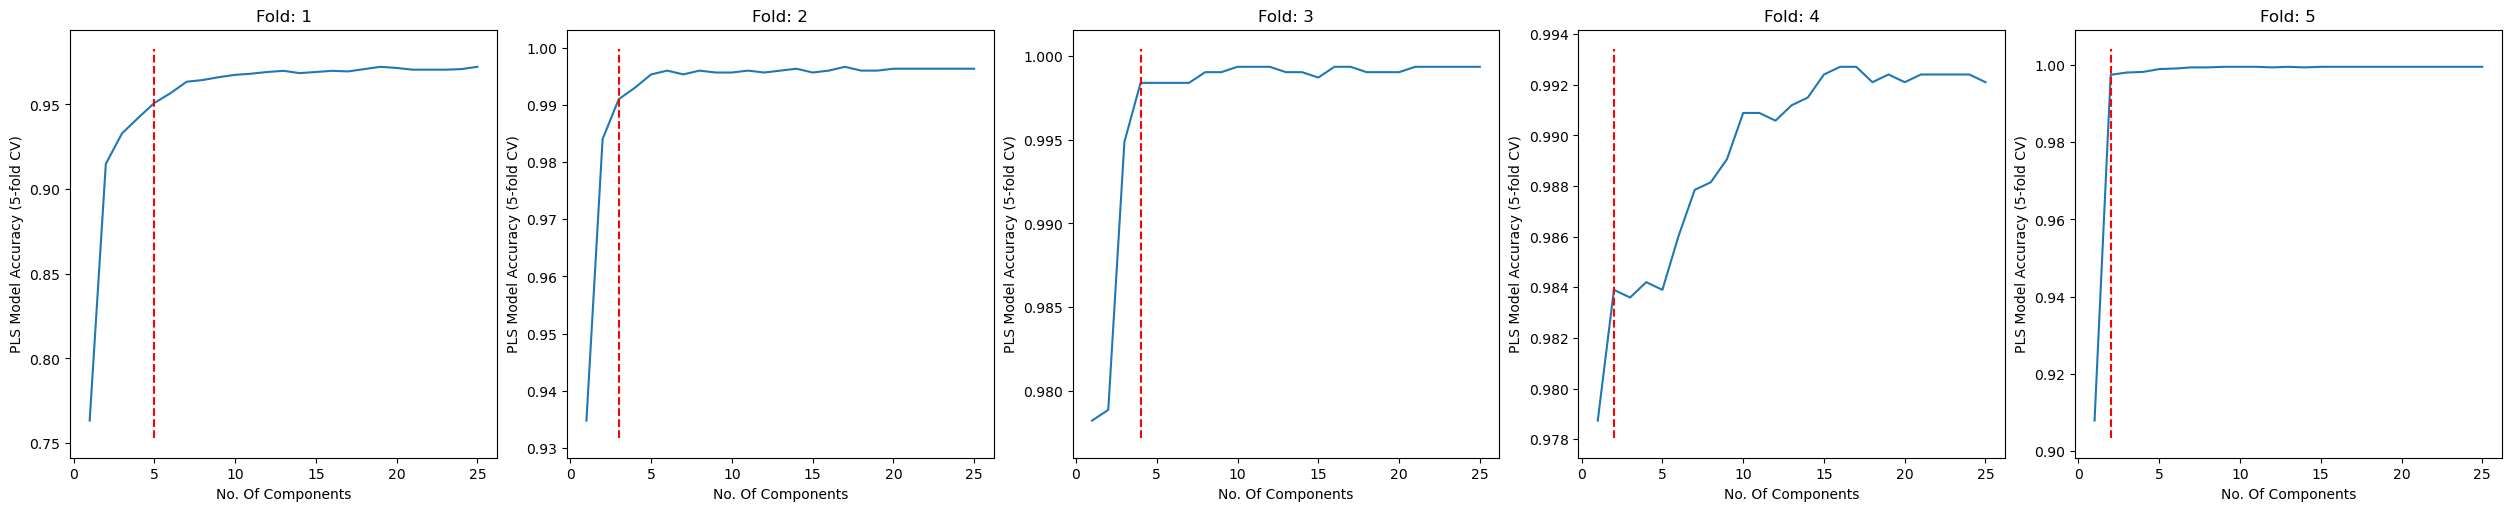

In [33]:
fig, ax = plt.subplots(ncols = 5, figsize = (25, 5), constrained_layout = True)

for fold in range(5):
    pls_model = condition_specific_pls_models[fold]
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[fold])
    ymin, ymax = ax[fold].get_ylim()
    ax[fold].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[fold].set_xlabel('No. Of Components')
    ax[fold].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[fold].set_title('Fold: {}'.format(fold + 1))


**Note, for fold 4, the automated elbow selection selects 2 components given the shape of the accuracy curve. After visual observation, we instead manually set it to 10**. 

In [40]:
fold = 3
condition_specific_pls_models[fold] = condition_specific_PLS(fold = fold, n_components = 10)

pls_model = condition_specific_pls_models[fold]
n_components = pls_model.n_components
q2y = pls_model.assessment_metrics['Q2Y']['value']
q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))

Fold: 4 | 10 components | Q2Y 0.570 (p = 9.90E-03)


In [41]:
io.write_pickled_object(
    condition_specific_pls_models,
    os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle')
)

# Test Conditions + Corresponding Controls

Same as above, but we include the controls for each cell type as well

In [19]:
cspcm = {}
for fold in trange(5):
    cspcm[fold] = condition_specific_PLS(fold, n_components = None, include_control = True)

  0%|                                                     | 0/5 [00:00<?, ?it/s]/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
100%|█████████████████████████████████████████████| 5/5 [04:20<00:00, 52.01s/it]


In [33]:
pls_model = cspcm[0]
n_iter = np.asarray(pls_model.n_iter_)

counter = 0
for fold, pls_model in cspcm.items():
    n_iter = np.asarray(pls_model.n_iter_)
    max_iter = getattr(pls_model, "max_iter", None)
    hit_cap = (max_iter is not None) and np.any(n_iter >= max_iter)
    if hit_cap:
        print('The PLS model for fold {} did not converge'.format(fold+1))
    else:
        counter += 1
if counter == 5:
    print('Any above convergence warnings are due to permuted models, not the actual model')



Any above convergence warnings are due to permuted models, not the actual model


Fold: 1 | 6 components | Q2Y 0.585 (p = 9.90E-03)
Fold: 2 | 5 components | Q2Y 0.676 (p = 9.90E-03)
Fold: 3 | 3 components | Q2Y 0.694 (p = 9.90E-03)
Fold: 4 | 3 components | Q2Y 0.715 (p = 9.90E-03)
Fold: 5 | 4 components | Q2Y 0.797 (p = 9.90E-03)


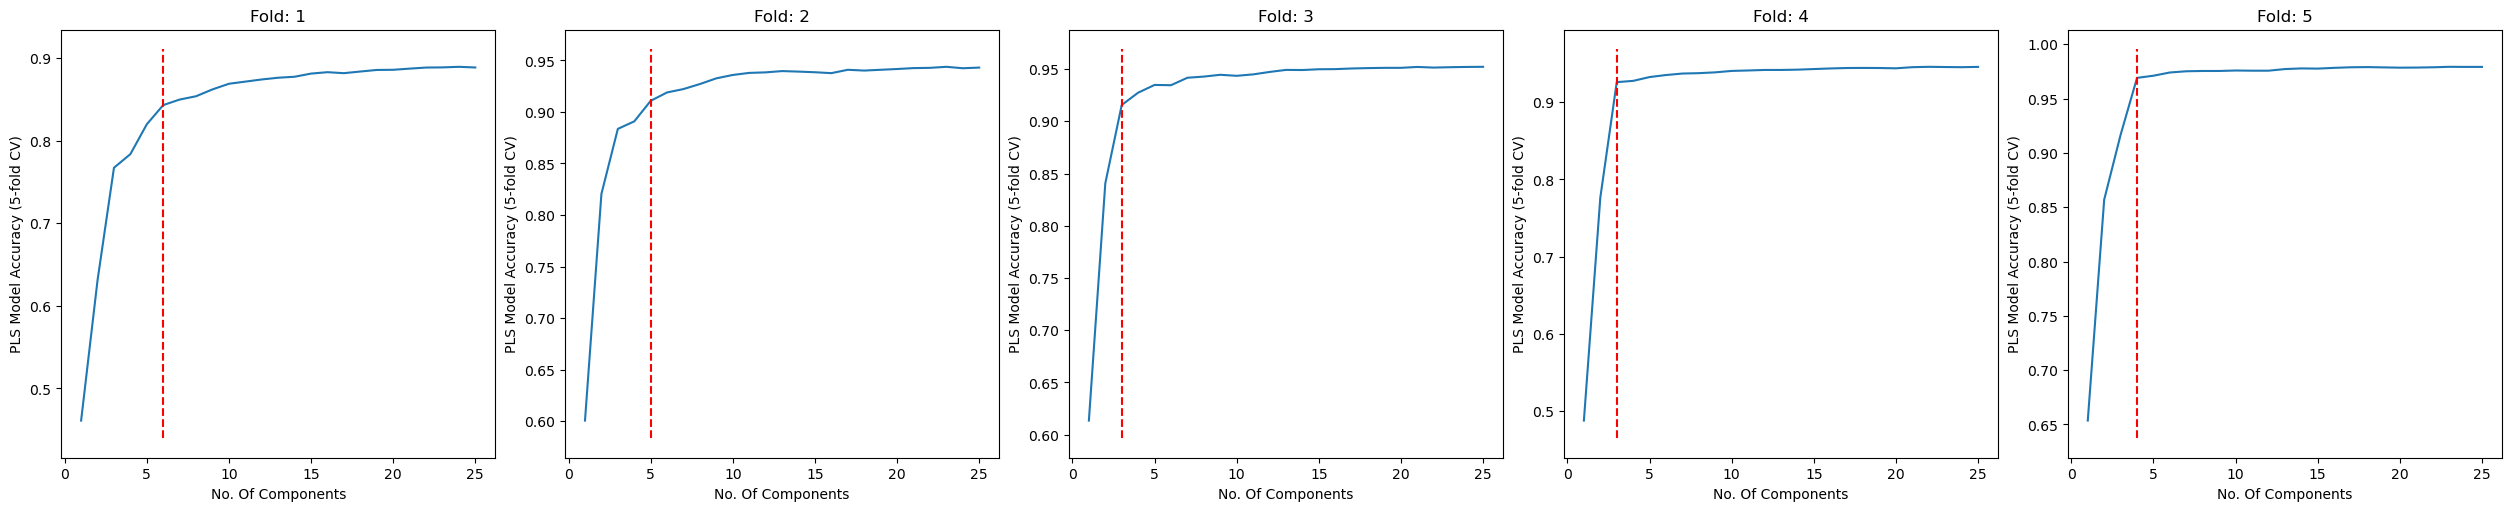

In [34]:
fig, ax = plt.subplots(ncols = 5, figsize = (25, 5), constrained_layout = True)

for fold in range(5):
    pls_model = cspcm[fold]
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[fold])
    ymin, ymax = ax[fold].get_ylim()
    ax[fold].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[fold].set_xlabel('No. Of Components')
    ax[fold].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[fold].set_title('Fold: {}'.format(fold + 1))


In [36]:
io.write_pickled_object(
    cspcm,
    os.path.join(data_path, 'interim', '{}_test_condition_PLS_models_with_control.pickle')
)

# Counterfactual Conditions

Here, for a given test condition, we fit the data to the counterfactual being asked (i.e., alongside the corresponding control for the same cell type). This will be looking out for separation betweeen control and perturbation

In [11]:
def counterfactual_pls_model(test_cond, n_components = None):
    """Fits PLS models specific to a counterfactual."""
    
    
    ct, pert = test_cond.split('^')
    ctrl_cond = '^'.join([ct, ctrl_pert])
    counterfactual_mask = tf_adata.obs.condition.isin([test_cond, ctrl_cond])
    tf_adata_test = tf_adata[counterfactual_mask,:].copy() 

    pls_model = run_pls_(tf_adata_test = tf_adata_test, n_components = n_components)
    
    return pls_model

In [7]:
# aggregate all test conditions
test_conditions_all = set()
for fold in range(5):
    split = get_split(fold, author)
    test_conds = split['test_conds']
#     for tc in test_conds:
    test_conditions_all.update(test_conds)
    
test_conds = sorted(test_conditions_all)

In [12]:
cf_pls_models = {}
for test_cond in tqdm(test_conds):
    cf_pls_models[test_cond] = counterfactual_pls_model(test_cond, n_components = None)

100%|███████████████████████████████████████████| 16/16 [02:16<00:00,  8.50s/it]


In [32]:
fig, ax = plt.subplots(ncols = 5, figsize = (25, 5), constrained_layout = True)

for (i, (test_cond, pls_model)) in enumerate(cf_pls_models.items()):
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[i])
    ymin, ymax = ax[i].get_ylim()
    ax[i].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[i].set_xlabel('No. Of Components')
    ax[i].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[i].set_title('Test Condition: {}'.format(' '.join(test_cond.split('^'))))


Test condition: Basal BMP4 | 4 components | Q2Y 0.785 (p = 9.90E-03)
Test condition: Basal IFNA2 | 2 components | Q2Y 0.886 (p = 9.90E-03)
Test condition: Basal IFNG | 5 components | Q2Y 0.944 (p = 9.90E-03)
Test condition: Basal IL13 | 5 components | Q2Y 0.848 (p = 9.90E-03)
Test condition: Basal TGFB1 | 5 components | Q2Y 0.912 (p = 9.90E-03)
Test condition: Club BMP4 | 3 components | Q2Y 0.777 (p = 9.90E-03)
Test condition: Club IFNA2 | 5 components | Q2Y 0.892 (p = 9.90E-03)
Test condition: Club IFNG | 6 components | Q2Y 0.548 (p = 9.90E-03)
Test condition: Club IL13 | 3 components | Q2Y 0.744 (p = 9.90E-03)
Test condition: Club TGFB1 | 6 components | Q2Y 0.400 (p = 9.90E-03)
Test condition: Goblet IFNA2 | 2 components | Q2Y 0.890 (p = 9.90E-03)
Test condition: Goblet IL13 | 3 components | Q2Y 0.698 (p = 9.90E-03)
Test condition: Multiciliated BMP4 | 3 components | Q2Y 0.523 (p = 9.90E-03)
Test condition: Multiciliated IFNA2 | 5 components | Q2Y 0.899 (p = 9.90E-03)
Test condition:

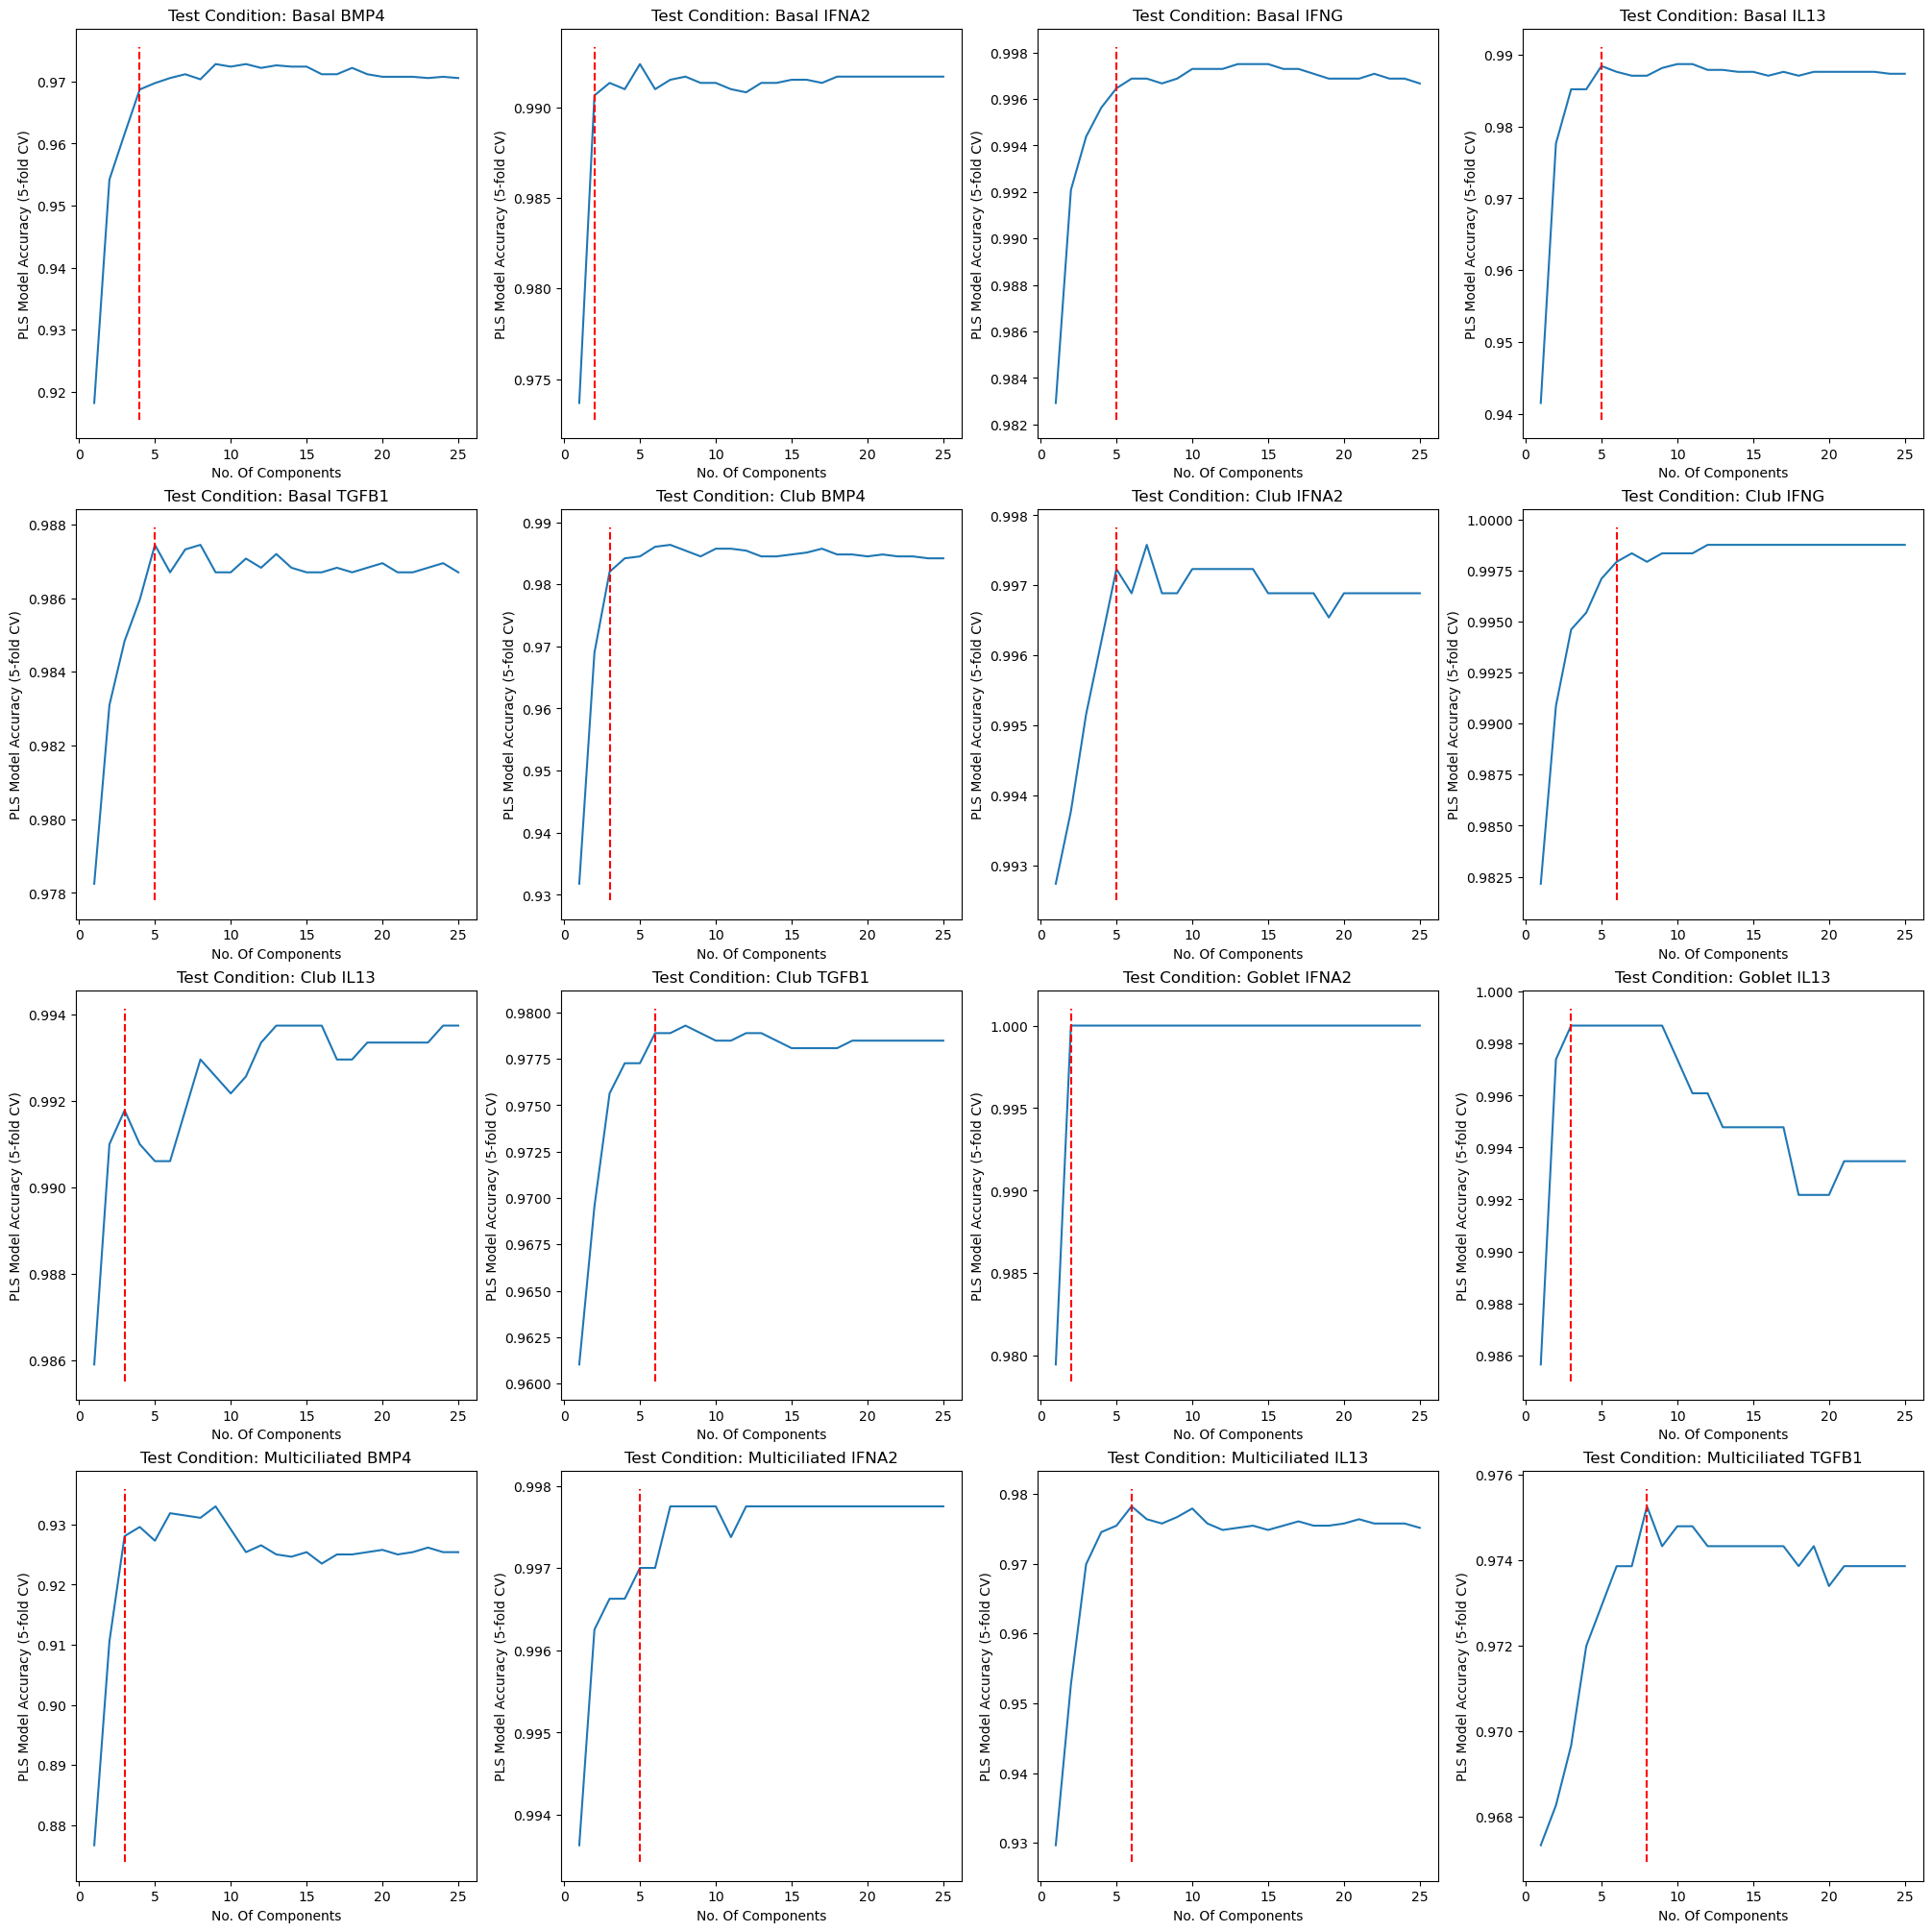

In [16]:
n_plots = len(cf_pls_models)
max_cols = 4
ncols = min(max_cols, n_plots)
nrows = math.ceil(n_plots / ncols)

fig, ax = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 5 * nrows),
    constrained_layout=True
)
ax = ax.flatten() if n_plots > 1 else [ax]

for (i, (test_cond, pls_model)) in enumerate(cf_pls_models.items()):
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Test condition: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(
        ' '.join(test_cond.split('^')), 
        n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[i])
    ymin, ymax = ax[i].get_ylim()
    ax[i].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[i].set_xlabel('No. Of Components')
    ax[i].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[i].set_title('Test Condition: {}'.format(' '.join(test_cond.split('^'))))

for j in range(i + 1, len(ax)):
    ax[j].axis('off')

In [17]:
io.write_pickled_object(
    cf_pls_models,
    os.path.join(data_path, 'interim', '{}_counterfactual_PLS_models.pickle')
)